<a href="https://colab.research.google.com/github/aj6781700/AI-ML-/blob/main/Tree_Visualization_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris, make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print('✓ Libraries loaded!')

✓ Libraries loaded!


## Part 2: Load Data

In [ ]:
# Load Iris dataset
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
class_names = iris.target_names

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f'Dataset: {len(X)} samples, {len(feature_names)} features')
print(f'Classes: {class_names}')

Dataset: 150 samples, 4 features
Classes: ['setosa' 'versicolor' 'virginica']


## Part 3: Train Decision Tree

In [ ]:
tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(X_train, y_train)

train_acc = tree.score(X_train, y_train)
test_acc = tree.score(X_test, y_test)

print(f'Training accuracy: {train_acc:.4f}')
print(f'Test accuracy: {test_acc:.4f}')
print(f'Tree depth: {tree.get_depth()}')
print(f'Number of leaves: {tree.get_n_leaves()}')

Training accuracy: 0.9524
Test accuracy: 1.0000
Tree depth: 3
Number of leaves: 5


## Part 4: sklearn plot_tree Visualization

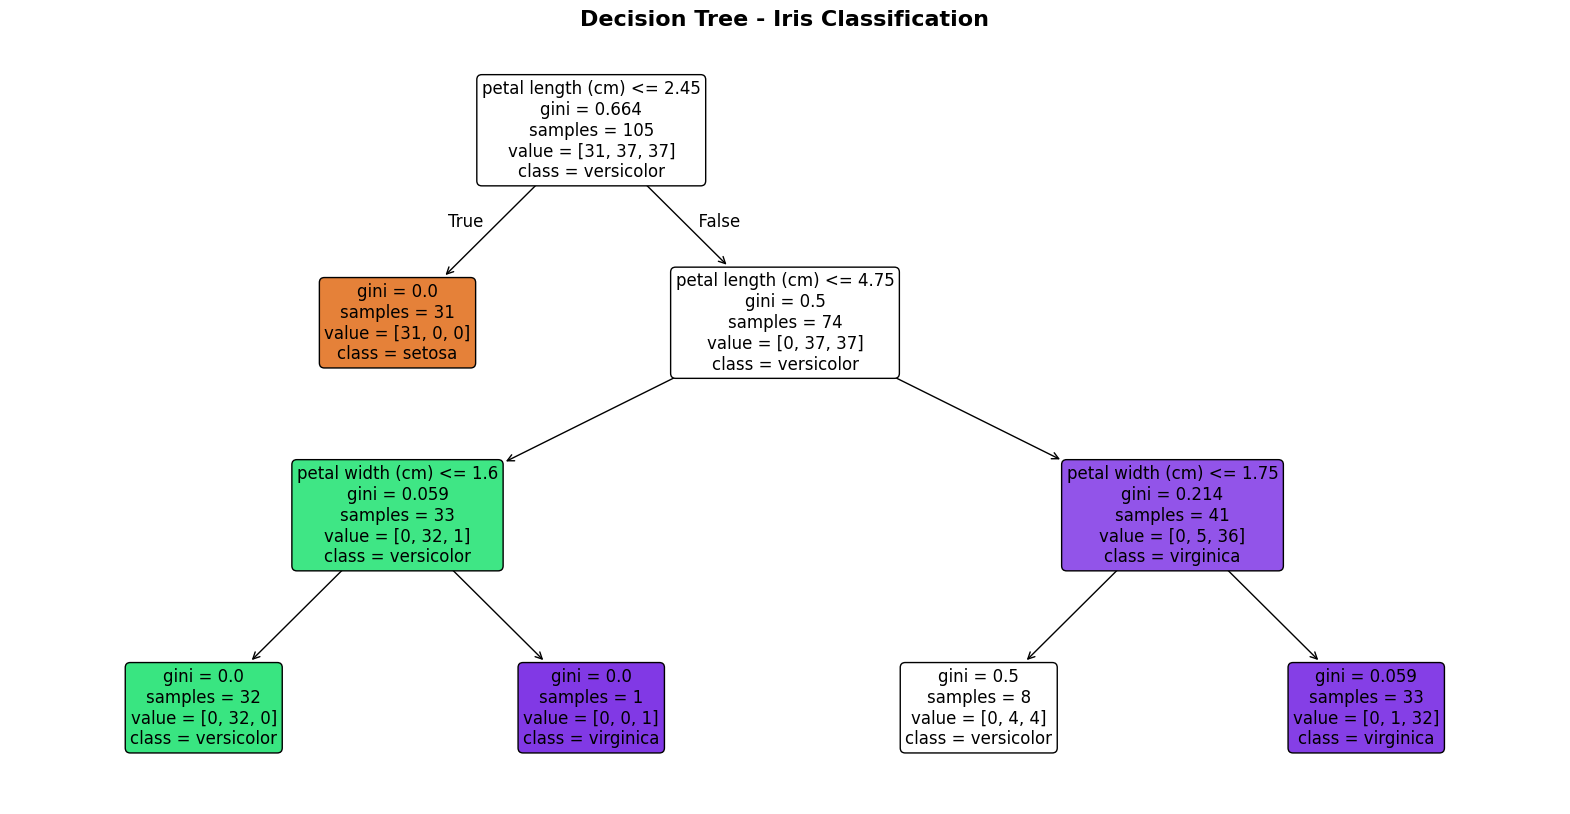

Node interpretation:
- Color: Majority class (darker = more pure)
- gini: Impurity (0 = pure, 0.5 = mixed)
- samples: Training samples in node
- value: [class_0, class_1, class_2] counts


In [ ]:
plt.figure(figsize=(20, 10))
plot_tree(tree,
          filled=True,
          feature_names=feature_names,
          class_names=list(class_names),
          rounded=True,
          fontsize=12)
plt.title('Decision Tree - Iris Classification', fontsize=16, fontweight='bold')
plt.show()

print('Node interpretation:')
print('- Color: Majority class (darker = more pure)')
print('- gini: Impurity (0 = pure, 0.5 = mixed)')
print('- samples: Training samples in node')
print('- value: [class_0, class_1, class_2] counts')

## Part 5: dtreeviz Visualization

In [ ]:
# Note: Uncomment if dtreeviz is installed
# from dtreeviz.trees import dtreeviz
#
# viz = dtreeviz(tree,
#                X_train,
#                y_train,
#                target_name='species',
#                feature_names=feature_names,
#                class_names=list(class_names))
# viz.view()

print('dtreeviz provides:')
print('1. Feature distribution histograms at each node')
print('2. Decision path highlighting')
print('3. Leaf node pie charts')
print('4. High-quality SVG export')
print('\nUncomment code above if dtreeviz is installed')

dtreeviz provides:
1. Feature distribution histograms at each node
2. Decision path highlighting
3. Leaf node pie charts
4. High-quality SVG export

Uncomment code above if dtreeviz is installed


## Part 6: Feature Importance (Impurity-Based)

FEATURE IMPORTANCE (Impurity-based)
petal length (cm)        : 0.9251
petal width (cm)         : 0.0749
sepal width (cm)         : 0.0000
sepal length (cm)        : 0.0000


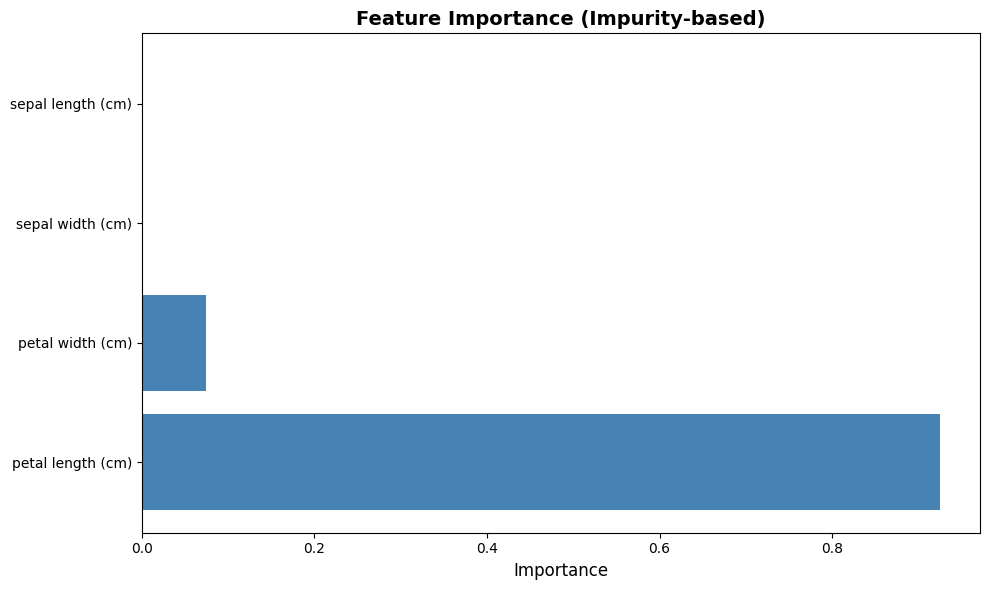

In [ ]:
importances = tree.feature_importances_
indices = np.argsort(importances)[::-1]

print('FEATURE IMPORTANCE (Impurity-based)')
print('='*50)
for i in indices:
    print(f'{feature_names[i]:25s}: {importances[i]:.4f}')
print('='*50)

# Visualize
plt.figure(figsize=(10, 6))
plt.barh(range(len(importances)), importances[indices], color='steelblue')
plt.yticks(range(len(importances)), [feature_names[i] for i in indices])
plt.xlabel('Importance', fontsize=12)
plt.title('Feature Importance (Impurity-based)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Part 7: Permutation Importance

In [ ]:
perm_importance = permutation_importance(tree, X_test, y_test, n_repeats=10, random_state=42)

print('\nPERMUTATION IMPORTANCE (Test Set)')
print('='*50)
for i in np.argsort(perm_importance.importances_mean)[::-1]:
    print(f'{feature_names[i]:25s}: {perm_importance.importances_mean[i]:.4f} ± {perm_importance.importances_std[i]:.4f}')
print('='*50)


PERMUTATION IMPORTANCE (Test Set)
petal length (cm)        : 0.5200 ± 0.0912
petal width (cm)         : 0.3000 ± 0.0318
sepal width (cm)         : 0.0000 ± 0.0000
sepal length (cm)        : 0.0000 ± 0.0000


## Part 8: Compare Importance Methods


IMPORTANCE METHOD COMPARISON
          Feature  Impurity  Permutation
petal length (cm)  0.925108         0.52
 petal width (cm)  0.074892         0.30
 sepal width (cm)  0.000000         0.00
sepal length (cm)  0.000000         0.00


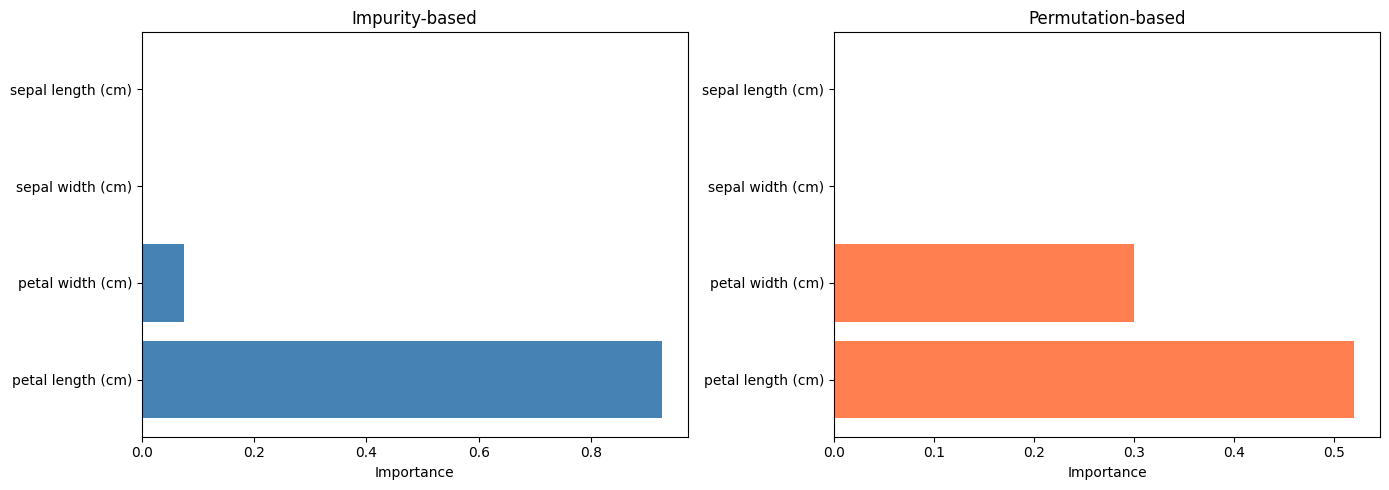

In [ ]:
comparison_df = pd.DataFrame({
    'Feature': feature_names,
    'Impurity': importances,
    'Permutation': perm_importance.importances_mean
})
comparison_df = comparison_df.sort_values('Impurity', ascending=False)

print('\nIMPORTANCE METHOD COMPARISON')
print(comparison_df.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(comparison_df['Feature'], comparison_df['Impurity'], color='steelblue')
axes[0].set_xlabel('Importance')
axes[0].set_title('Impurity-based')

axes[1].barh(comparison_df['Feature'], comparison_df['Permutation'], color='coral')
axes[1].set_xlabel('Importance')
axes[1].set_title('Permutation-based')

plt.tight_layout()
plt.show()

## Part 9: Decision Path Tracing

In [ ]:
# Trace decision path for first test sample
sample_idx = 0
sample = X_test[sample_idx].reshape(1, -1)

path = tree.decision_path(sample)
node_indicator = path.toarray()[0]
node_indices = np.where(node_indicator)[0]

print(f'\nDECISION PATH FOR SAMPLE {sample_idx}')
print('='*50)
print(f'True class: {class_names[y_test[sample_idx]]}')
print(f'Predicted: {class_names[tree.predict(sample)[0]]}')
print(f'\nFeatures: {sample[0]}')
print(f'\nPath through tree:')

for node_id in node_indices:
    if node_id == 0:
        print(f'Node {node_id}: ROOT')
    else:
        print(f'Node {node_id}')


DECISION PATH FOR SAMPLE 0
True class: versicolor
Predicted: versicolor

Features: [6.1 2.8 4.7 1.2]

Path through tree:
Node 0: ROOT
Node 2
Node 3
Node 4


## Summary

**Key Learnings:**
- ✓ plot_tree for quick debugging
- ✓ dtreeviz for presentations (if installed)
- ✓ Feature importance reveals what model uses
- ✓ Permutation importance measures actual predictive power
- ✓ Decision paths explain individual predictions

**Next Steps:** Ensemble methods (Random Forests, Gradient Boosting)

---

**Vishlesan i-Hub IIT Patna × Masai School**